Data import

In [1]:
import pandas as pd 
import numpy as np

In [2]:
Sales           = pd.read_parquet('PraquetDATA/Sales.parquet')
Purchase        = pd.read_parquet('PraquetDATA/Purchase.parquet')
Future_Price    = pd.read_csv('CSVDATA/2017PurchasePricesDec.csv')
Purchase_invoice= pd.read_csv('CSVDATA/InvoicePurchases12312016.csv')
Invoice_Begin   = pd.read_csv('CSVDATA/BegInvFINAL12312016.csv')
Invoice_End     = pd.read_csv('CSVDATA/EndInvFINAL12312016.csv')

Fill some Nan Values

In [3]:
Purchase.loc[Purchase['Brand']==15365 , 'Size'] = '750mL'
Purchase.loc[Purchase['Brand']==3121 , 'Size'] = '750mL'
Purchase.loc[Purchase['Brand']==5678 , 'Size'] = '750mL'

Changing Date Dtypes

In [4]:
Invoice_Begin['startDate']  = pd.to_datetime(Invoice_Begin['startDate']).dt.normalize()
Invoice_End['endDate']      = pd.to_datetime(Invoice_End['endDate']).dt.normalize()
Purchase_invoice[['InvoiceDate','PODate','PayDate']]=Purchase_invoice[['InvoiceDate','PODate','PayDate']].apply(pd.to_datetime).apply(lambda x: x.dt.normalize())

Creating weekly data

In [5]:
Sales['Week']       = (((Sales['SalesDate'].dt.dayofyear - 1) // 7) + 1).clip(upper=52).astype('uint8')
Purchase['Week']    = (((Purchase['ReceivingDate'].dt.dayofyear - 1) // 7) + 1).clip(upper=52).astype('uint8')

Reconciliation of Usual SKU

In [6]:
Permanent_SKU= set(set(Sales['Brand']) & set(Invoice_Begin['Brand']) & set(Invoice_End['Brand']))
print(len(Permanent_SKU))

6933


In [7]:
Sales[Sales['Brand'].isin(Permanent_SKU)][["SalesDollars","SalesQuantity"]].astype('Float64').sum()

SalesDollars     430903999.739258
SalesQuantity          30806116.0
dtype: Float64

Thank u chat gpt (this is a reference for slicing checks)

In [8]:
sales_ids = set(Sales['Brand'].unique())
begin_ids = set(Invoice_Begin['Brand'].unique())
end_ids   = set(Invoice_End['Brand'].unique())

print("Sales:", len(sales_ids))
print("Begin:", len(begin_ids))
print("End:", len(end_ids))

print("All 3:", len(sales_ids & begin_ids & end_ids))
print("Begin only:", len(begin_ids - end_ids))
print("End only:", len(end_ids - begin_ids))

Sales: 11237
Begin: 8094
End: 9653
All 3: 6933
Begin only: 1106
End only: 2665


items that got removed mid year

In [9]:
#DS discontinued stock
DS = set(Invoice_Begin['Brand']) - set(Invoice_End['Brand'])
len(DS)

1106

In [10]:
All_Sold_DS =  set(Sales[Sales['Brand'].isin(DS)]['Brand'])
print(len(All_Sold_DS))

1090


In [11]:
All_Purchased_DS = DS & set(Purchase['Brand'])
print(len(All_Purchased_DS))

631


In [12]:
All_Purchased_Sold_DS = All_Sold_DS & All_Purchased_DS
print(len(All_Purchased_Sold_DS))

631


In [13]:
All_Non_Purchased_DS = All_Sold_DS - All_Purchased_DS
print(len(All_Non_Purchased_DS))

459


In [14]:
All_Vanished_DS = DS - All_Sold_DS
print(len(All_Vanished_DS))

16


In [15]:
#overview of removed mid year
print('all Sold value & QTE')
print('Total SKUs: ' ,len(All_Sold_DS),' S/Q ',Sales[Sales['Brand'].isin(All_Sold_DS)]['SalesDollars'].astype('int64').sum(),' & ' , Sales[Sales['Brand'].isin(All_Sold_DS)]['SalesQuantity'].astype('int64').sum()  )
print('all Sold/Purchased value & QTE')
print('Total SKUs: ' ,len(All_Purchased_Sold_DS),' S/Q ',Sales[Sales['Brand'].isin(All_Purchased_Sold_DS)]['SalesDollars'].astype('int64').sum(),' & ' , Sales[Sales['Brand'].isin(All_Purchased_Sold_DS)]['SalesQuantity'].astype('int64').sum()  )
print('all Non Purchased value & QTE')
print('Total SKUs: ' ,len(All_Non_Purchased_DS),' S/Q ',Sales[Sales['Brand'].isin(All_Non_Purchased_DS)]['SalesDollars'].astype('int64').sum(),' & ' , Sales[Sales['Brand'].isin(All_Non_Purchased_DS)]['SalesQuantity'].astype('int64').sum()  )
print('all Purchased value & QTE')
print('Total SKUs: ' ,len(All_Purchased_DS),' S/Q ',Purchase[Purchase['Brand'].isin(All_Purchased_DS)]['Dollars'].astype('int64').sum(),' & ' , Purchase[Purchase['Brand'].isin(All_Purchased_DS)]['Quantity'].astype('int64').sum()  )

all Sold value & QTE
Total SKUs:  1090  S/Q  3023560  &  221787
all Sold/Purchased value & QTE
Total SKUs:  631  S/Q  2885225  &  216113
all Non Purchased value & QTE
Total SKUs:  459  S/Q  138335  &  5674
all Purchased value & QTE
Total SKUs:  631  S/Q  1181983  &  115681


In [16]:
#starting inventory for DS
print('all DS  I QTE')
print('Total SKUs: ' ,len(DS),' Q ', Invoice_Begin[Invoice_Begin['Brand'].isin(DS)]['onHand'].sum())
print('all Sold/Purchased I QTE')
print('Total SKUs: ' ,len(All_Purchased_Sold_DS),' Q ', Invoice_Begin[Invoice_Begin['Brand'].isin(All_Purchased_Sold_DS)]['onHand'].sum()  )
print('all Non Purchased I QTE')
print('Total SKUs: ' ,len(All_Non_Purchased_DS),' Q ', Invoice_Begin[Invoice_Begin['Brand'].isin(All_Non_Purchased_DS)]['onHand'].sum()  )
print('all Purchased  I QTE')
print('Total SKUs: ' ,len(All_Purchased_DS),' Q ', Invoice_Begin[Invoice_Begin['Brand'].isin(All_Purchased_DS)]['onHand'].sum()  )
print('all  Vanished I QTE')
print('Total SKUs: ' ,len(All_Vanished_DS),' Q ', Invoice_Begin[Invoice_Begin['Brand'].isin(All_Vanished_DS)]['onHand'].sum()  )

all DS  I QTE
Total SKUs:  1106  Q  106106
all Sold/Purchased I QTE
Total SKUs:  631  Q  100432
all Non Purchased I QTE
Total SKUs:  459  Q  5674
all Purchased  I QTE
Total SKUs:  631  Q  100432
all  Vanished I QTE
Total SKUs:  16  Q  0


items that got Added mid year

In [17]:
#AAS all added stock
AAS = set(set(Invoice_End['Brand'])-set(Invoice_Begin['Brand']))
print(Invoice_End[Invoice_End['Brand'].isin(AAS)]['Brand'].nunique())

2665


In [18]:
AAS_Sold = set(Sales[Sales['Brand'].isin(AAS)]['Brand'])
print('Sold:   ' , len(AAS_Sold))

Sold:    2470


In [19]:
AAS_Purchased = set(Purchase[Purchase['Brand'].isin(AAS)]['Brand'])
print('Purchased: ' ,len(AAS_Purchased))

Purchased:  2647


In [20]:
AAS_spawned_end=set (Invoice_End[Invoice_End['Brand'].isin(AAS_Purchased-AAS_Sold)])
print('Purchased: ' ,len(AAS_spawned_end))

Purchased:  9


In [21]:
AAS_Sold_Purchased = set(AAS_Purchased&AAS_Sold)
print('Purchased: ' ,len(AAS_Sold_Purchased))

Purchased:  2470


In [22]:
AAS_spawned=set (AAS_Purchased-AAS_Sold)
print('Purchased: ' ,len(AAS_spawned))

Purchased:  177


In [23]:
AAS_Not_Purchased = AAS - AAS_Purchased
print('Purchased: ' ,len(AAS_Not_Purchased))

Purchased:  18


In [24]:
#overview of removed mid year
print('all Sold value & QTE')
print('Total SKUs: ' ,len(AAS_Sold),' S/Q ',Sales[Sales['Brand'].isin(AAS_Sold)]['SalesDollars'].astype('int64').sum(),' & ' , Sales[Sales['Brand'].isin(AAS_Sold)]['SalesQuantity'].astype('int64').sum()  )
print('all Sold/Purchased value & QTE')
print('Total SKUs: ' ,len(AAS_Sold_Purchased),' S/Q ',Sales[Sales['Brand'].isin(AAS_Sold_Purchased)]['SalesDollars'].astype('int64').sum(),' & ' , Sales[Sales['Brand'].isin(AAS_Sold_Purchased)]['SalesQuantity'].astype('int64').sum()  )
print('all Non Purchased value & QTE')
print('Total SKUs: ' ,len(AAS_Not_Purchased),' S/Q ',Sales[Sales['Brand'].isin(AAS_Not_Purchased)]['SalesDollars'].astype('int64').sum(),' & ' , Sales[Sales['Brand'].isin(AAS_Not_Purchased)]['SalesQuantity'].astype('int64').sum()  )
print('all Purchased value & QTE')
print('Total SKUs: ' ,len(AAS_Purchased),' S/Q ',Purchase[Purchase['Brand'].isin(AAS_Purchased)]['Dollars'].astype('int64').sum(),' & ' , Purchase[Purchase['Brand'].isin(AAS_Purchased)]['Quantity'].astype('int64').sum()  )


all Sold value & QTE
Total SKUs:  2470  S/Q  15931441  &  1769180
all Sold/Purchased value & QTE
Total SKUs:  2470  S/Q  15931441  &  1769180
all Non Purchased value & QTE
Total SKUs:  18  S/Q  0  &  0
all Purchased value & QTE
Total SKUs:  2647  S/Q  18261203  &  2321385


In [25]:
#starting inventory for DS
print('all DS  I QTE')
print('Total SKUs: ' ,len(AAS),' Q ', Invoice_End[Invoice_End['Brand'].isin(AAS)]['onHand'].sum())
print('all Sold/Purchased I QTE')
print('Total SKUs: ' ,len(AAS_Sold_Purchased),' Q ', Invoice_End[Invoice_End['Brand'].isin(AAS_Sold_Purchased)]['onHand'].sum()  )
print('all Non Purchased I QTE')
print('Total SKUs: ' ,len(AAS_Not_Purchased),' Q ', Invoice_End[Invoice_End['Brand'].isin(AAS_Not_Purchased)]['onHand'].sum()  )
print('all Purchased  I QTE')
print('Total SKUs: ' ,len(AAS_Purchased),' Q ', Invoice_End[Invoice_End['Brand'].isin(AAS_Purchased)]['onHand'].sum()  )
print('all  Vanished I QTE')
print('Total SKUs: ' ,len(AAS_spawned),' Q ', Invoice_End[Invoice_End['Brand'].isin(AAS_spawned)]['onHand'].sum()  )

all DS  I QTE
Total SKUs:  2665  Q  552205
all Sold/Purchased I QTE
Total SKUs:  2470  Q  539501
all Non Purchased I QTE
Total SKUs:  18  Q  0
all Purchased  I QTE
Total SKUs:  2647  Q  552205
all  Vanished I QTE
Total SKUs:  177  Q  12704


Items that entered and left same year

In [26]:
test_Sku= set(Sales['Brand'])-set(Invoice_Begin['Brand'])-set(Invoice_End['Brand'])
print(len(test_Sku))

744


Stock reconciliation

In [27]:
Store_recon =  Sales.groupby(['Store','Brand'], observed=True)['SalesQuantity'].sum().reset_index().merge(
    Purchase.groupby(['Store','Brand'], observed=True)['Quantity'].sum().reset_index(),on=['Store','Brand'],how='outer').merge(
        Invoice_Begin.groupby(['Store','Brand'], observed=True)['onHand'].sum().reset_index(),on=['Store','Brand'],how='outer'
    ).merge(Invoice_End.groupby(['Store','Brand'], observed=True)['onHand'].sum().reset_index(),on=['Store','Brand'],how='outer'
    )

In [28]:
Store_recon = Store_recon [['Store','Brand','onHand_x','Quantity','SalesQuantity','onHand_y']]

In [29]:
Store_recon[['onHand_x','Quantity','SalesQuantity','onHand_y']].sum()

onHand_x          4219275.0
Quantity         33584377.0
SalesQuantity    32917876.0
onHand_y          4885776.0
dtype: float64

In [30]:
Store_recon = Store_recon.fillna(0)

In [31]:
Store_recon['C_end']= Store_recon['onHand_x'] + Store_recon['Quantity'] - Store_recon['SalesQuantity']

In [32]:
Store_recon['DIFF']= Store_recon['C_end']-Store_recon['onHand_y']

In [33]:
Store_recon[Store_recon['DIFF'] != 0] 

,Store,Brand,onHand_x,Quantity,SalesQuantity,onHand_y,C_end,DIFF


Brand reconciliation

In [34]:
brand_recon = Store_recon.groupby('Brand')[['onHand_x',"Quantity" ,'SalesQuantity','onHand_y','C_end','DIFF']].sum().reset_index()

In [35]:
brand_recon[brand_recon['Brand'].isin(AAS)].sum()

Brand            52888904.0
onHand_x                0.0
Quantity          2321385.0
SalesQuantity     1769180.0
onHand_y           552205.0
C_end              552205.0
DIFF                    0.0
dtype: float64

In [36]:
brand_recon[brand_recon['Brand'].isin(Permanent_SKU)].sum()

Brand            121930620.0
onHand_x           4113014.0
Quantity          31026506.0
SalesQuantity     30806116.0
onHand_y           4333404.0
C_end              4333404.0
DIFF                     0.0
dtype: float64

In [37]:
brand_recon[brand_recon['Brand'].isin(DS)].sum()

Brand            17507488.0
onHand_x           106106.0
Quantity           115681.0
SalesQuantity      221787.0
onHand_y                0.0
C_end                   0.0
DIFF                    0.0
dtype: float64

In [38]:
brand_recon[brand_recon['Brand'].isin(test_Sku)].sum()

Brand            14488151.0
onHand_x                0.0
Quantity           120793.0
SalesQuantity      120793.0
onHand_y                0.0
C_end                   0.0
DIFF                    0.0
dtype: float64

ABC analysis

Store Competitiveness

In [39]:
S_Competitive= Sales.groupby('Store').sum(numeric_only=True).sort_values(by=['SalesDollars','SalesQuantity'],ascending=[False,False])[['SalesQuantity','SalesDollars']]

In [40]:
S_Competitive['percentage']       = (S_Competitive['SalesDollars']/S_Competitive['SalesDollars'].sum())*100
S_Competitive['percentage_Cumul'] = S_Competitive['percentage'].cumsum()

In [41]:
S_Competitive.loc[S_Competitive['percentage_Cumul'] <= 50 , 'ABC'] = 'A'
S_Competitive.loc[S_Competitive['percentage_Cumul'] > 50 , 'ABC'] = 'B'
S_Competitive.loc[S_Competitive['percentage_Cumul'] > 80 , 'ABC'] = 'C'

In [42]:
S_Competitive.reset_index(inplace=True)

Products Competitiveness (company overall)

Permanent Sku

In [43]:
len(Permanent_SKU)

6933

In [44]:
Company_ABC = Sales[Sales['Brand'].isin(Permanent_SKU)].groupby('Brand').sum(numeric_only=True).sort_values(by=['SalesDollars','SalesQuantity'],ascending=[False,False])[['SalesQuantity','SalesDollars']]

In [45]:
Company_ABC.reset_index(inplace=True)

In [46]:
Company_ABC['percentage']       = (Company_ABC['SalesDollars']/Company_ABC['SalesDollars'].sum())*100
Company_ABC['percentage_Cumul'] = Company_ABC['percentage'].cumsum()

In [47]:
Company_ABC['Countpercentage']   = ((Company_ABC.index + 1) / len(Company_ABC)) * 100

In [48]:
Company_ABC['X-Y'] = Company_ABC['percentage_Cumul']-Company_ABC['Countpercentage']

In [49]:
Company_ABC['Marginal contribution'] = (Company_ABC['percentage_Cumul'].diff()/Company_ABC['Countpercentage'].iloc[0])

In [50]:
Company_ABC.at[0,'Marginal contribution']= float(round(Company_ABC['percentage_Cumul'].iloc[0]/Company_ABC['Countpercentage'].iloc[0] , 7))

In [51]:
Company_ABC['marginal_sku_density']= 1 / Company_ABC['percentage']

In [52]:
Company_ABC['efficiency_k1'] = Company_ABC['percentage_Cumul']-Company_ABC['marginal_sku_density']

In [53]:
Company_ABC['ultra_efficiency_k2']= Company_ABC['efficiency_k1']-Company_ABC['marginal_sku_density']

In [54]:
Company_ABC.loc[Company_ABC['Marginal contribution'] >= 1  , 'ABC'] = 'B'
Company_ABC.loc[Company_ABC['percentage_Cumul'] <= Company_ABC[Company_ABC['efficiency_k1']==Company_ABC['efficiency_k1'].max()]['percentage_Cumul'].values[0]  , 'ABC'] = 'A'
Company_ABC.loc[Company_ABC['Marginal contribution'] < 1  , 'ABC'] = 'C'

In [55]:
Company_ABC['efficiency_k1'].max()

np.float32(34.79322)

<Axes: xlabel='Countpercentage'>

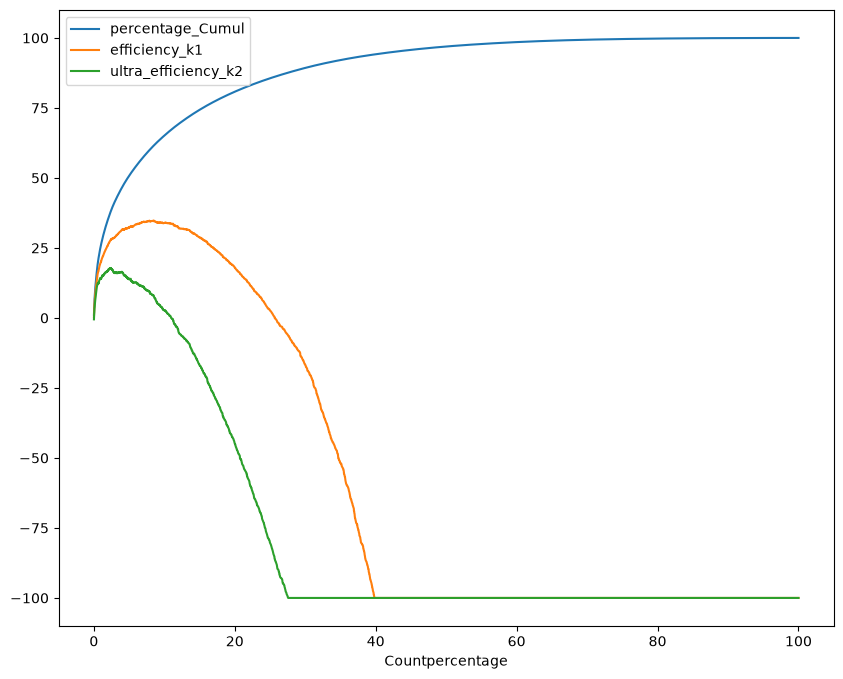

In [56]:
Company_ABC[['Countpercentage','percentage_Cumul','efficiency_k1','ultra_efficiency_k2']].assign(
    efficiency_k1       =Company_ABC['efficiency_k1'].clip(lower=-100),
    ultra_efficiency_k2 =Company_ABC['ultra_efficiency_k2'].clip(lower=-100)
).plot(

     x = 'Countpercentage' ,
     y =['percentage_Cumul','efficiency_k1','ultra_efficiency_k2']
   
    ,kind='line',

    sharey=False,
    figsize=(10, 8)
    )

Stock level through the year for permanent SKU

In [57]:
# Permanent Sku weekly sales PWS
PWS = (
    Sales[Sales['Brand'].isin(Permanent_SKU) ][['Brand', 'Week', 'SalesQuantity']]
    .groupby(['Brand', 'Week'])['SalesQuantity'].sum()
)
PWS_grid = PWS.unstack(level='Week', fill_value=0)
PWS_grid.columns = PWS_grid.columns.astype(str)

In [58]:
# Permanent Sku weekly sales PWP
PWP = (
    Purchase[Purchase['Brand'].isin(Permanent_SKU) ][['Brand', 'Week', 'Quantity']]
    .groupby(['Brand', 'Week'])['Quantity'].sum()
)
PWP_grid = PWP.unstack(level='Week', fill_value=0)
PWP_grid.columns = PWP_grid.columns.astype(str)

In [59]:
PWP_grid.reset_index(inplace=True)

In [60]:
IS=PWP_grid[['Brand','1']].copy() 
IS=IS.merge(Invoice_Begin[Invoice_Begin['Brand'].isin(Permanent_SKU)][['Brand','onHand']].groupby('Brand',as_index=False).sum(), on='Brand', how='outer').fillna(0)
IS['X']= IS['1'].fillna(0)+IS['onHand'].fillna(0)

In [61]:
PWP_grid.drop(columns = '1' , inplace = True)
PWP_grid= PWP_grid.merge(IS[['Brand','X']],on='Brand',how = 'outer').fillna(0)
x = PWP_grid.pop('X')
PWP_grid.insert(1,'1',x)

In [62]:
PWS_grid.reset_index(inplace=True)

In [63]:
# Stock level Grid for permanent items Permanent_SLG
Permanent_SLG = PWP_grid.set_index('Brand').cumsum(axis=1) - PWS_grid.set_index('Brand').cumsum(axis=1)

In [64]:
(Permanent_SLG.isnull().sum()).sum()

np.int64(0)

In [65]:
# 1. Standardize all column names to integers across all three grids
#PWS_grid.columns      = [int(c) if str(c).isdigit() else c for c in PWS_grid.columns]
#PWP_grid.columns      = [int(c) if str(c).isdigit() else c for c in PWP_grid.columns]
#Permanent_SLG.columns = [int(c) if str(c).isdigit() else c for c in Permanent_SLG.columns]

# 2. Extract only integer week columns (automatically ignores 'Brand', 'CSW', 'Mean', etc.)
# week_cols = [c for c in Permanent_SLG.columns if isinstance(c, int)] we didnt use this one cuz we made all columns into str 
week_cols = [c for c in Permanent_SLG.columns if str(c).isdigit()]
# 3. Align PWS and PWP row order to match Permanent_SLG's index exactly
pws_aligned = (PWS_grid.set_index('Brand') if 'Brand' in PWS_grid.columns else PWS_grid).reindex(Permanent_SLG.index).fillna(0)
pwp_aligned = (PWP_grid.set_index('Brand') if 'Brand' in PWP_grid.columns else PWP_grid).reindex(Permanent_SLG.index).fillna(0)

# 4. Calculate stockouts strictly on week columns
true_stockout_matrix = (
    (Permanent_SLG[week_cols] <= 0) & 
    (pws_aligned[week_cols] == 0) & 
    (pwp_aligned[week_cols] == 0)
)

# 5. Assign CSW
Permanent_SLG['CSW'] = true_stockout_matrix.sum(axis=1)

In [66]:
Permanent_SLG.reset_index(inplace=True)

XYZ

In [67]:
PWS_grid=PWS_grid.merge(Permanent_SLG[['Brand','CSW']],on='Brand',how='left')

In [68]:
PWS_grid

,Brand,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,CSW
0,58,45,43,51,69,58,56,93,68,71,...,67,64,56,69,62,69,100,108,129,0
1,60,27,23,28,21,31,29,21,28,9,...,69,184,104,163,124,143,256,192,98,0
2,61,12,12,0,0,0,12,0,24,0,...,0,24,0,0,24,0,0,0,12,0
3,62,24,28,30,28,32,52,62,66,48,...,53,45,28,56,35,41,61,83,129,0
4,63,24,20,24,25,33,50,51,61,30,...,47,46,28,52,46,39,48,76,114,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6928,90086,0,0,1,0,1,0,0,0,0,...,0,1,4,0,0,2,2,2,1,0
6929,90087,0,0,0,1,0,0,1,0,0,...,0,0,0,0,1,1,0,0,0,0
6930,90088,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,2,0
6931,90089,0,1,1,12,13,0,4,0,0,...,0,0,3,5,0,0,6,1,12,0


In [69]:
PWS_grid['Mean'] = PWS_grid.drop(columns=['Brand','CSW']).sum(axis=1)/(52-PWS_grid['CSW'])

PWS_grid['Std']  =np.sqrt( 
    (PWS_grid.drop(columns=['Brand','CSW' , 'Mean']).sub(PWS_grid['Mean'], axis=0))
    .pow(2)
    .sum(axis=1) / (52 - PWS_grid['CSW'] - 1)

)
PWS_grid['CV']   =(PWS_grid['Std']/PWS_grid['Mean'])*100

In [70]:
PWS_grid.loc[PWS_grid['CV'] <= 50, 'XYZ']   = 'X'
PWS_grid.loc[PWS_grid['CV'] > 50, 'XYZ']    = 'Y'
PWS_grid.loc[PWS_grid['CV'] > 100, 'XYZ']   = 'Z'
PWS_grid.loc[PWS_grid['CV'].isna(), 'XYZ']   = 'Z'

In [71]:
ABC_XYZ = Company_ABC.merge(PWS_grid[['Brand','XYZ']],on=['Brand'],how='left')

In [72]:
ABC_XYZ['Tier']=ABC_XYZ['ABC']+ABC_XYZ['XYZ']

In [73]:
ABC_XYZ.groupby('Tier')[['SalesQuantity' ,'SalesDollars' ,'percentage']].sum()

,SalesQuantity,SalesDollars,percentage
Tier,,,
AX,10387509,169469696.0,39.328873
AY,4680273,81705880.0,18.961504
AZ,705492,14047672.0,3.260046
BX,5741421,53834908.0,12.493480
BY,2258966,31408896.0,7.289070
BZ,402439,5341071.5,1.239504
CX,3616647,32879472.0,7.630347
CY,2238527,30566574.0,7.093592
CZ,774842,11649819.0,2.703576


Creating new Permanent clasification

In [74]:
Permanent_SKU_XY = set(ABC_XYZ[(ABC_XYZ['XYZ']=='X') | (ABC_XYZ['XYZ']=='Y') ]['Brand'])

In [75]:
Permanent_SKU_Z = set(ABC_XYZ[(ABC_XYZ['XYZ']=='Z') ]['Brand'])

In [76]:
Permanent_SKU_Ghost = set(PWS_grid[PWS_grid['Mean']<1]['Brand'])

Demand Forcasting

Creating lead time

In [77]:
Sales['Month']=(Sales['SalesDate'].dt.month).astype('int8')

In [78]:
Purchase['lead']=(Purchase['ReceivingDate']-Purchase['PODate']).dt.days.astype('int8')

Lead table for permanent sku

In [79]:
# Permanent_LT is permanent sku lead table
Permanent_LT = (
    Purchase[Purchase['Brand'].isin(Permanent_SKU)].groupby(['Brand','VendorName'])['lead'].agg(
    avg_lead= 'mean',
    std_lead = 'std'
).reset_index()
)

In [80]:
Permanent_LT['CV'] = Permanent_LT['std_lead'] / Permanent_LT['avg_lead']

In [81]:
Permanent_LT.loc[Permanent_LT['CV'] <=0.2 , 'XYZ']   = 'X'
Permanent_LT.loc[Permanent_LT['CV'] > 0.2 , 'XYZ']   = 'Y'
Permanent_LT.loc[Permanent_LT['CV'] > 1   , 'XYZ']   = 'Z'
Permanent_LT['XYZ'] = Permanent_LT['XYZ'].fillna('Z')
Permanent_LT['XYZ'] = Permanent_LT['XYZ'].astype('category')

SAles forcasting

Permanent

In [82]:
Forcast_P_XY = PWS_grid[PWS_grid['Brand'].isin(Permanent_SKU_XY) ].drop(columns=['Mean','Std','CV' , 'XYZ'])

In [83]:
Forcast_P_XY

,Brand,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,CSW
0,58,45,43,51,69,58,56,93,68,71,...,67,64,56,69,62,69,100,108,129,0
3,62,24,28,30,28,32,52,62,66,48,...,53,45,28,56,35,41,61,83,129,0
4,63,24,20,24,25,33,50,51,61,30,...,47,46,28,52,46,39,48,76,114,0
5,72,7,2,2,6,6,9,9,12,11,...,1,7,2,17,6,5,14,10,11,0
7,77,134,191,178,191,178,200,268,223,181,...,177,237,276,292,196,229,252,329,412,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6910,46985,20,52,68,40,69,19,37,38,25,...,86,67,53,111,120,52,31,87,58,0
6911,47009,17,10,37,20,43,32,65,53,24,...,32,26,40,71,29,47,36,58,66,0
6913,47014,35,65,79,52,78,54,69,73,49,...,66,86,87,134,60,62,50,117,113,0
6914,47027,15,14,21,15,24,21,36,19,14,...,8,24,23,17,17,11,16,34,15,0


In [84]:
Anomaly_F_P_XY = Forcast_P_XY[Forcast_P_XY['CSW']>0]

In [85]:
Anomaly_F_P_XY

,Brand,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,CSW
517,1771,0,0,0,0,0,0,0,39,303,...,565,478,504,609,501,616,853,1301,1446,7
543,1891,3,0,0,0,0,0,0,0,0,...,6,13,5,10,14,7,20,31,36,9
550,1927,0,0,0,0,0,0,0,5,13,...,37,24,39,36,15,36,56,86,88,7
557,1982,0,0,0,0,0,0,2,16,11,...,55,67,62,66,60,56,67,120,124,6
598,2109,15,4,3,6,7,1,0,0,1,...,15,14,9,32,25,17,35,56,58,1
647,2230,0,0,0,2,3,4,5,7,14,...,15,12,16,11,16,7,15,14,18,3
805,2715,0,0,0,0,0,2,2,8,12,...,8,8,9,12,12,10,11,14,22,4
982,3084,3,0,0,0,3,0,0,0,0,...,41,36,34,41,33,50,59,99,63,8
1043,3288,0,0,12,50,52,42,52,54,59,...,8,11,11,5,1,1,2,1,5,1
1050,3306,14,5,7,8,17,2,5,3,0,...,14,27,25,34,26,24,40,51,49,11


In [86]:
Forcast_P_XY=Forcast_P_XY.drop(Anomaly_F_P_XY.index)

In [87]:
Forcast_P_XY=Forcast_P_XY.set_index('Brand').drop(columns='CSW')

In [88]:
week_cols = [str(i) for i in range(1, 53)]

COMPARING PERMANENT SKUS WITHOUT THE ONES THAT GOT STOCKOUTS

CREATING SIMPLE MOVING AVERAGE SMA

SMA 3

In [89]:
Permanent_SMA_3 = (
    Forcast_P_XY[week_cols]
    .T
    .rolling(window=3, min_periods=3)
    .mean()
    .T
    .astype('float32')
    .round(2)
)


SMA 4

In [90]:
Permanent_SMA_4 = (
    Forcast_P_XY[week_cols]
    .T
    .rolling(window=4, min_periods=4)
    .mean()
    .T
    .astype('float32')
    .round(2)
)


SMA 5

In [91]:
Permanent_SMA_5 = (
    Forcast_P_XY[week_cols]
    .T
    .rolling(window=5, min_periods=5)
    .mean()
    .T
    .astype('float32')
    .round(2)
)


SMA 8 

In [92]:
Permanent_SMA_8 = (
    Forcast_P_XY[week_cols]
    .T
    .rolling(window=8, min_periods=8)
    .mean()
    .T
    .astype('float32')
    .round(2)
)


SMA 13 

In [93]:
Permanent_SMA_13 = (
    Forcast_P_XY[week_cols]
    .T
    .rolling(window=13, min_periods=13)
    .mean()
    .T
    .astype('float32')
    .round(2)
)


COMPARING SMA ACROSS SKUs

In [94]:
droping_columns = [str(i) for i in range(1,13)]

In [95]:
#droping the first periode
PXSMA3   =Permanent_SMA_3.drop(columns=droping_columns )
PXSMA4   =Permanent_SMA_4.drop(columns=droping_columns )
PXSMA5   =Permanent_SMA_5.drop(columns=droping_columns )
PXSMA8   =Permanent_SMA_8.drop(columns=droping_columns )
PXSMA13  =Permanent_SMA_13.drop(columns=droping_columns)


In [96]:
PXSMA = Forcast_P_XY.drop(columns=droping_columns)

In [97]:
PXSMA3 =Permanent_SMA_3.reindex_like(PXSMA).astype('float64').round(2)
PXSMA4 =Permanent_SMA_4.reindex_like(PXSMA).astype('float64').round(2)
PXSMA5 =Permanent_SMA_5.reindex_like(PXSMA).astype('float64').round(2)
PXSMA8 =Permanent_SMA_8.reindex_like(PXSMA).astype('float64').round(2)
PXSMA13=Permanent_SMA_13.reindex_like(PXSMA).astype('float64').round(2)

In [98]:
PXSMA=PXSMA.astype('float64').round(2)

In [99]:
#sanity check
print((PXSMA3.isnull().sum()).sum())
print((PXSMA4.isnull().sum()).sum())
print((PXSMA5.isnull().sum()).sum())
print((PXSMA8.isnull().sum()).sum())
print((PXSMA13.isnull().sum()).sum())
print((PXSMA.isnull().sum()).sum())

0
0
0
0
0
0


In [100]:
PermanentX_SMA_graph = pd.DataFrame(
    {
        'Actual'      : PXSMA.sum(),
        'SMA_3'       : PXSMA3.sum(),
        'SMA_4'       : PXSMA4.sum(),
        'SMA_5'       : PXSMA5.sum(),
        'SMA_8'       : PXSMA8.sum(),
        'SMA_13'      : PXSMA13.sum()
        
    }
)

<Axes: title={'center': 'Weekly Demand Trajectory: Actuals vs SMA Models'}>

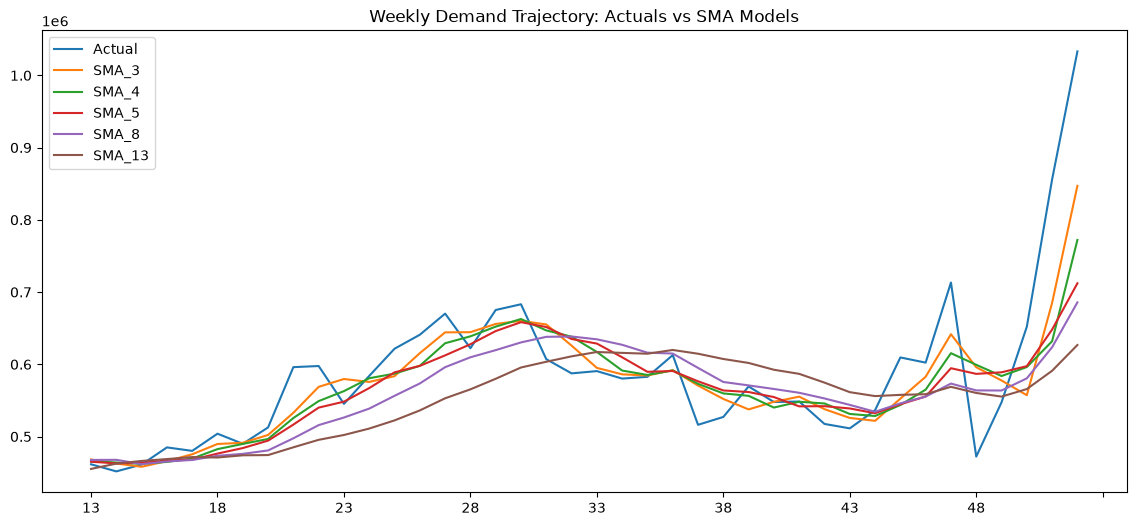

In [101]:
PermanentX_SMA_graph.plot(figsize=(14, 6),title="Weekly Demand Trajectory: Actuals vs SMA Models")

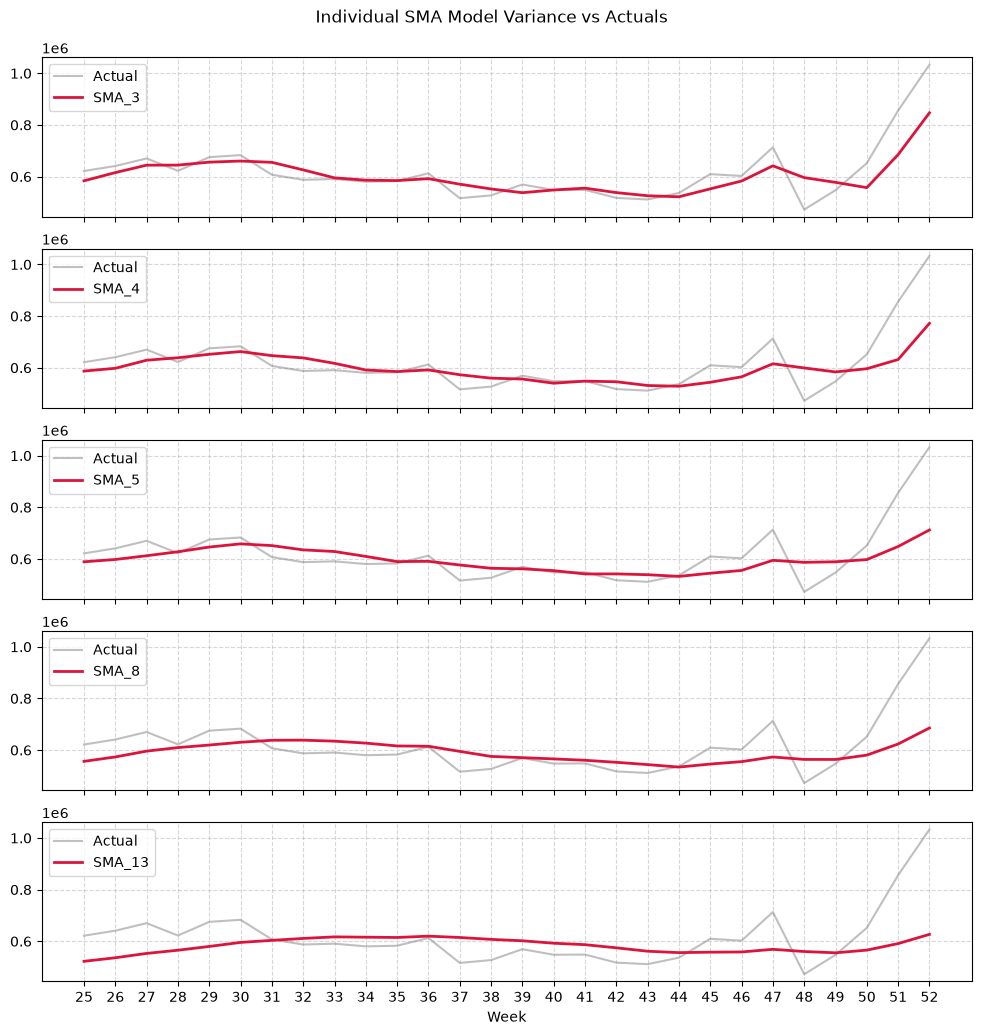

In [102]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)

sma_cols = ['SMA_3', 'SMA_4', 'SMA_5', 'SMA_8', 'SMA_13']

for ax, col in zip(axes, sma_cols):
    ax.plot(PermanentX_SMA_graph.index[12:], PermanentX_SMA_graph['Actual'].iloc[12:], label='Actual', color='gray', alpha=0.5)
    ax.plot(PermanentX_SMA_graph.index[12:], PermanentX_SMA_graph[col].iloc[12:], label=col, color='crimson', linewidth=2)
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.xlabel("Week")
plt.suptitle("Individual SMA Model Variance vs Actuals", y=0.92)
plt.show()

Weight moving average

Weighted moving average periode 3

In [103]:
PXWMA3 = (
    3 * Forcast_P_XY + 
    2 * Forcast_P_XY.shift(1, axis=1) + 
    1 * Forcast_P_XY.shift(2, axis=1)
) / 6

Weighted moving average periode 4

In [104]:
PXWMA4 = (
    4 * Forcast_P_XY + 
    3 * Forcast_P_XY.shift(1, axis=1) + 
    2 * Forcast_P_XY.shift(2, axis=1) + 
    1 * Forcast_P_XY.shift(3, axis=1) 
) / 10

Weighted moving average periode 5

In [105]:
PXWMA5 = (
    5 * Forcast_P_XY + 
    4 * Forcast_P_XY.shift(1, axis=1) +
    3 * Forcast_P_XY.shift(2, axis=1) + 
    2 * Forcast_P_XY.shift(3, axis=1) + 
    1 * Forcast_P_XY.shift(4, axis=1) 
) / 15

Weighted moving average periode 8

In [106]:
PXWMA8 = (
    8 * Forcast_P_XY + 
    7 * Forcast_P_XY.shift(1, axis=1) +
    6 * Forcast_P_XY.shift(2, axis=1) +
    5 * Forcast_P_XY.shift(3, axis=1) +
    4 * Forcast_P_XY.shift(4, axis=1) +
    3 * Forcast_P_XY.shift(5, axis=1) + 
    2 * Forcast_P_XY.shift(6, axis=1) + 
    1 * Forcast_P_XY.shift(7, axis=1) 
) / 36

Weighted moving average periode 13

In [107]:
PXWMA13 = (
    13 * Forcast_P_XY + 
    12 * Forcast_P_XY.shift(1, axis=1) +
    11 * Forcast_P_XY.shift(2, axis=1) +
    10 * Forcast_P_XY.shift(3, axis=1) +
    9 * Forcast_P_XY.shift(4, axis=1) +
    8 * Forcast_P_XY.shift(5, axis=1) +
    7 * Forcast_P_XY.shift(6, axis=1) +
    6 * Forcast_P_XY.shift(7, axis=1) +
    5 * Forcast_P_XY.shift(8, axis=1) +
    4 * Forcast_P_XY.shift(9, axis=1) +
    3 * Forcast_P_XY.shift(10, axis=1) + 
    2 * Forcast_P_XY.shift(11, axis=1) + 
    1 * Forcast_P_XY.shift(12, axis=1) 
) / 91

removing columns

In [108]:
droping_columns = [str(i) for i in range(1,13)]

In [109]:
#droping the first periode
PXWMA3.drop(columns=droping_columns ,inplace=True)
PXWMA4.drop(columns=droping_columns ,inplace=True)
PXWMA5.drop(columns=droping_columns ,inplace=True)
PXWMA8.drop(columns=droping_columns ,inplace=True)
PXWMA13.drop(columns=droping_columns,inplace=True)

In [110]:
PXWMA=Forcast_P_XY.drop(columns=droping_columns)

In [111]:
PXWMA3 =PXWMA3.reindex_like(PXWMA).astype('float64').round(2)
PXWMA4 =PXWMA4.reindex_like(PXWMA).astype('float64').round(2)
PXWMA5 =PXWMA5.reindex_like(PXWMA).astype('float64').round(2)
PXWMA8 =PXWMA8.reindex_like(PXWMA).astype('float64').round(2)
PXWMA13=PXWMA13.reindex_like(PXWMA).astype('float64').round(2)
PXWMA=PXSMA.astype('float64').round(2)

In [112]:
#sanity check
print((PXWMA3.isnull().sum()).sum())
print((PXWMA4.isnull().sum()).sum())
print((PXWMA5.isnull().sum()).sum())
print((PXWMA8.isnull().sum()).sum())
print((PXWMA13.isnull().sum()).sum())
print((PXWMA.isnull().sum()).sum())

0
0
0
0
0
0


Graph demonstration

In [113]:
PermanentX_WMA_graph = pd.DataFrame(
    {
        'Actual'      : PXWMA.sum(),
        'WMA_3'       : PXWMA3.sum(),
        'WMA_4'       : PXWMA4.sum(),
        'WMA_5'       : PXWMA5.sum(),
        'WMA_8'       : PXWMA8.sum(),
        'WMA_13'      : PXWMA13.sum()
        
    }
)

<Axes: title={'center': 'Weekly Demand Trajectory: Actuals vs WMA Models'}, xlabel='Week', ylabel='demand'>

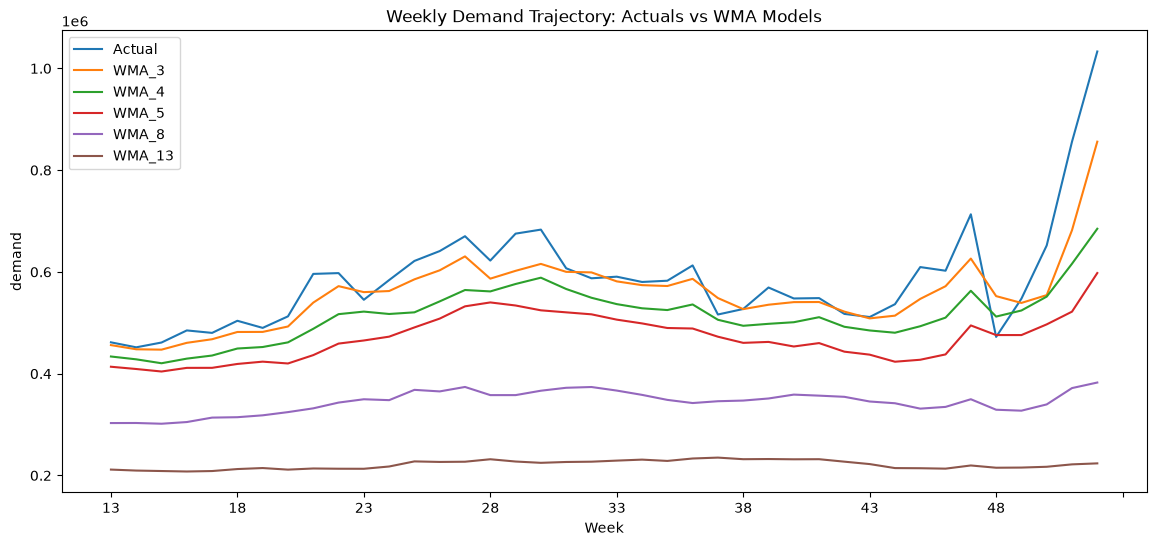

In [159]:
PermanentX_WMA_graph.plot(figsize=(14, 6),xlabel='Week',ylabel='demand',title="Weekly Demand Trajectory: Actuals vs WMA Models")

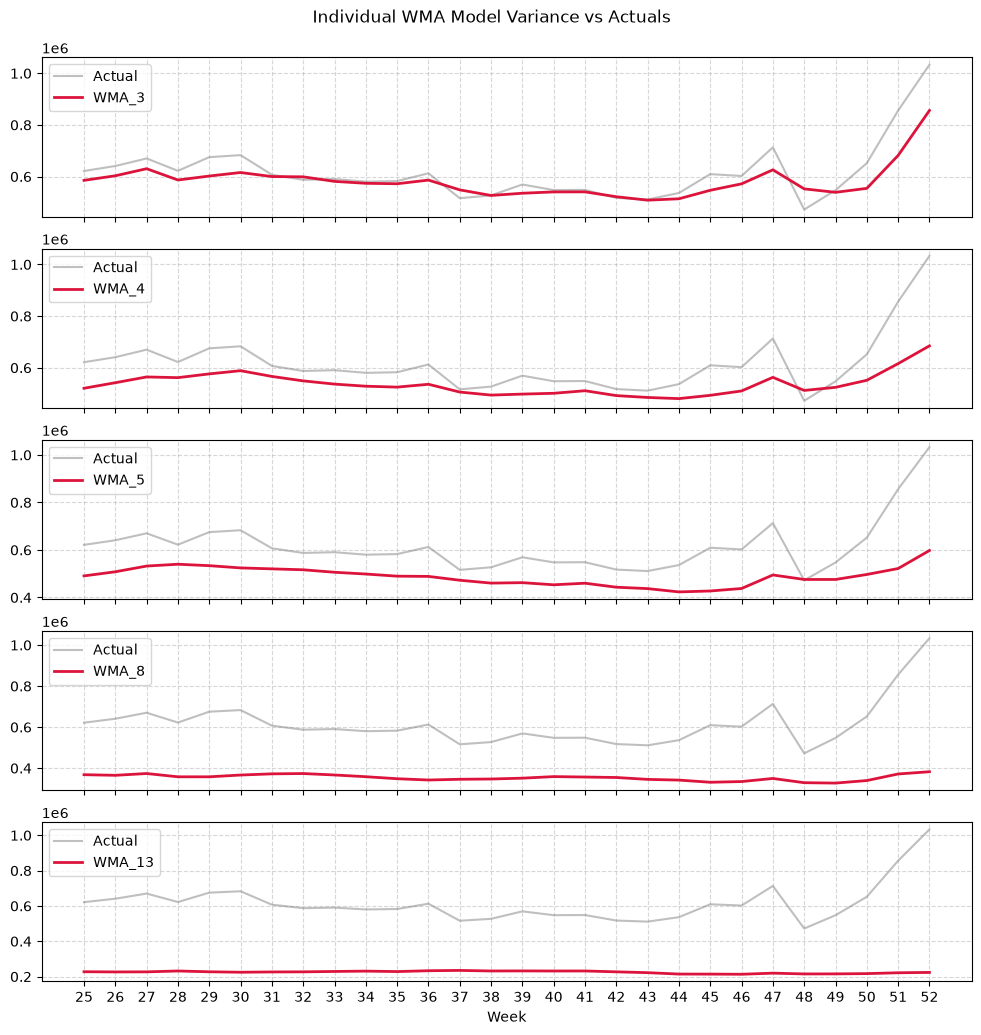

In [115]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)

sma_cols = ['WMA_3', 'WMA_4', 'WMA_5', 'WMA_8', 'WMA_13']

for ax, col in zip(axes, sma_cols):
    ax.plot(PermanentX_WMA_graph.index[12:], PermanentX_WMA_graph['Actual'].iloc[12:], label='Actual', color='gray', alpha=0.5)
    ax.plot(PermanentX_WMA_graph.index[12:], PermanentX_WMA_graph[col].iloc[12:], label=col, color='crimson', linewidth=2)
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.xlabel("Week")
plt.suptitle("Individual WMA Model Variance vs Actuals", y=0.92)
plt.show()

Exponential smoothing SES

In [ ]:
'''yes ai coding on this one not me cuz i wanted to find the optimal alpha and i have no clue how however i understand partially how this code works
basicaly what it does is 
test if all the values in the row are equal to the first row in order to know if its just a flat line 
then it check each sku one by one and give them an optimal alpha 
if there is a numerical issue the code just default to 0.5
'''
import numpy as np
import pandas as pd
from statsmodels.tsa.api import SimpleExpSmoothing
from tqdm import tqdm

# Assumptions:
# Forcast_P_XY is your (4112 SKUs x 52 Weeks) DataFrame of actual weekly sales

# 1. Arrays to hold fitted 52-week values and optimal alphas
ses_fitted_52_weeks = []
optimal_alphas = []

print("Recreating 52-week historical period using optimal SES per SKU...")

for idx, row in tqdm(Forcast_P_XY.iterrows(), total=len(Forcast_P_XY)):
    sales_data = row.values.astype(float)
    
    # Handle flat / zero-demand series
    if np.all(sales_data == sales_data[0]):
        ses_fitted_52_weeks.append(sales_data)
        optimal_alphas.append(0.0)
        continue
        
    try:
        # Fit SES model on full history to optimize alpha
        model = SimpleExpSmoothing(sales_data, initialization_method="estimated").fit(optimized=True)
        
        # Extract optimal alpha parameter
        alpha_opt = model.params['smoothing_level']
        optimal_alphas.append(alpha_opt)
        
        # Get the 52-week fitted values (in-sample historical reconstruction)
        fitted_series = model.fittedvalues
        ses_fitted_52_weeks.append(fitted_series)
        
    except Exception:
        # Fallback to naive actuals if optimization encounters a numerical issue
        ses_fitted_52_weeks.append(sales_data)
        optimal_alphas.append(0.5)

Recreating 52-week historical period using optimal SES per SKU...


 47%|████▋     | 1920/4112 [00:03<00:04, 500.27it/s]c:\Users\anoir\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:1065: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  res = self._optimize_parameters(res, use_brute, method, minimize_kwargs)
 49%|████▉     | 2020/4112 [00:04<00:04, 458.68it/s]c:\Users\anoir\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:1065: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  res = self._optimize_parameters(res, use_brute, method, minimize_kwargs)
 58%|█████▊    | 2368/4112 [00:04<00:03, 497.56it/s]c:\Users\anoir\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:1065: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  res = self._optimize_parameters(res, use_brute, method, minimize_kwargs)
 90%|████████▉ | 3683/4112 [00:07<00:00, 517.39it/s]c:\

In [124]:

PXSES = pd.DataFrame(ses_fitted_52_weeks, index=Forcast_P_XY.index, columns=Forcast_P_XY.columns)

SES GRPAH

In [125]:
PermanentX_SES_graph = pd.DataFrame(
    {
        'Actual'      : Forcast_P_XY.sum(),
        'OPTIMAL SES' : PXSES.sum()
        
    }
)

<Axes: title={'center': 'Weekly Demand Trajectory: Actuals vs SES Models'}, xlabel='Week', ylabel='demand'>

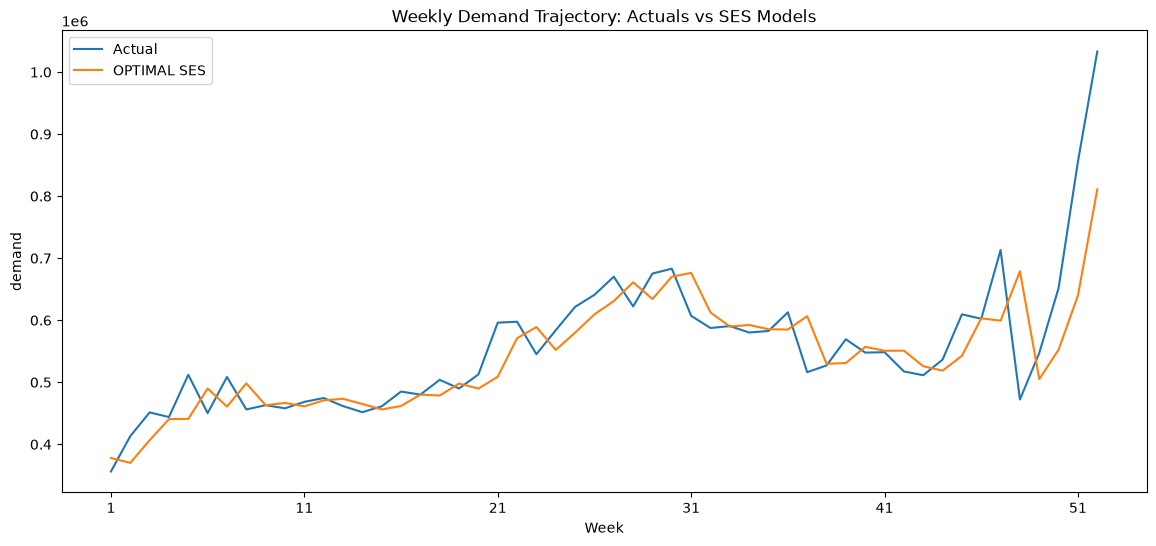

In [158]:
PermanentX_SES_graph.plot(figsize=(14, 6),xlabel='Week',ylabel='demand',title="Weekly Demand Trajectory: Actuals vs SES Models")

In [141]:
PXSES.drop(columns=droping_columns,inplace=True)

Holt leaniar exponential smoothing

In [147]:
import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import Holt
from tqdm import tqdm

# Assuming df_sales is your 52-week input matrix (4,112 SKUs x 52 Weeks)
holt_fitted_list = []
optimal_params = []

for idx, row in tqdm(Forcast_P_XY.iterrows(),total=len(Forcast_P_XY)):
    series = row.values
    
    # 1. Flat/Zero line check (Same logic as SES)
    if np.all(series == series[0]):
        holt_fitted_list.append(series)
        optimal_params.append({'alpha': 0.0, 'beta': 0.0})
        continue
        
    try:
        # 2. Fit Holt's Linear Model (optimizing alpha & beta via L-BFGS-B)
        model = Holt(series, damped_trend=True, initialization_method='estimated').fit(optimized=True)
        
        # In-sample fitted values (52 weeks)
        fitted_vals = model.fittedvalues
        
        # Extract optimal alpha and beta
        alpha_opt = model.params.get('smoothing_level', 0.0)
        beta_opt = model.params.get('smoothing_trend', 0.0)
        
        holt_fitted_list.append(fitted_vals)
        optimal_params.append({'alpha': alpha_opt, 'beta': beta_opt})
        
    except Exception:
        # 3. Solver exception fallback (return raw sales)
        holt_fitted_list.append(series)
        optimal_params.append({'alpha': np.nan, 'beta': np.nan})


 18%|█▊        | 741/4112 [00:05<00:25, 131.68it/s]c:\Users\anoir\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:1065: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  res = self._optimize_parameters(res, use_brute, method, minimize_kwargs)
 50%|█████     | 2058/4112 [00:15<00:17, 119.66it/s]c:\Users\anoir\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:1065: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  res = self._optimize_parameters(res, use_brute, method, minimize_kwargs)
 79%|███████▉  | 3243/4112 [00:24<00:06, 137.19it/s]c:\Users\anoir\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:1065: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  res = self._optimize_parameters(res, use_brute, method, minimize_kwargs)
 89%|████████▉ | 3667/4112 [00:27<00:03, 133.41it/s]c:\U

In [169]:
PXHOLT = pd.DataFrame(holt_fitted_list, index=Forcast_P_XY.index, columns=Forcast_P_XY.columns)
PXHOLT_params = pd.DataFrame(optimal_params, index=Forcast_P_XY.index)

HOLT GRAPH

In [150]:
PermanentX_HAULT_graph = pd.DataFrame(
    {
        'Actual'      : Forcast_P_XY.sum(),
        'OPTIMAL SES' : PXHOLT.sum()
        
    }
)

<Axes: title={'center': 'Weekly Demand Trajectory: Actuals vs Hault Model'}, xlabel='Week', ylabel='demand'>

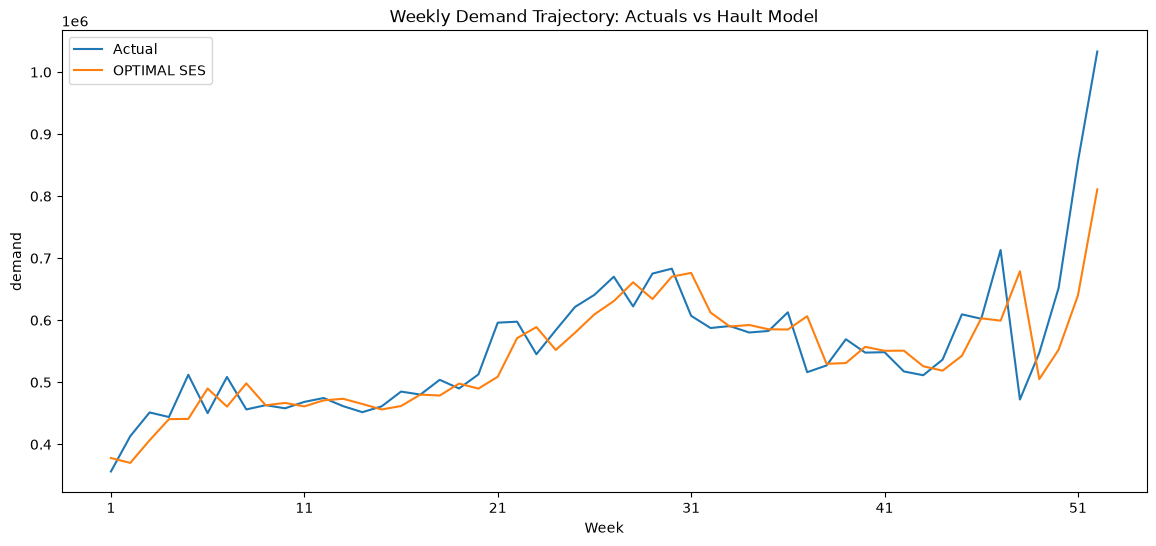

In [157]:
PermanentX_SES_graph.plot(figsize=(14, 6) ,xlabel='Week',ylabel='demand',title="Weekly Demand Trajectory: Actuals vs Hault Model" )

In [170]:
PXHOLT.drop(columns=droping_columns,inplace = True)

damped leanear holt

In [168]:
import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import Holt
from tqdm import tqdm

holt_damped_fitted_list = []
optimal_params_damped = []

for idx, row in tqdm(Forcast_P_XY.iterrows(), total=len(Forcast_P_XY), desc="Fitting Damped Holt"):
    series = row.values.astype(float)
    
    # 1. Flat/Zero line check
    if np.all(series == series[0]):
        holt_damped_fitted_list.append(series)
        optimal_params_damped.append({'alpha': 0.0, 'beta': 0.0, 'phi': 1.0})
        continue
        
    try:
        # 2. Fit Damped Holt's Model (damped_trend=True)
        model = Holt(series, damped_trend=True, initialization_method='estimated').fit(optimized=True)
        
        # In-sample fitted values (52 weeks)
        fitted_vals = model.fittedvalues
        
        # Extract optimal alpha, beta, and phi (damping factor)
        alpha_opt = model.params.get('smoothing_level', 0.0)
        beta_opt = model.params.get('smoothing_trend', 0.0)
        phi_opt = model.params.get('damping_trend', 1.0)  # <-- Added damping coefficient
        
        holt_damped_fitted_list.append(fitted_vals)
        optimal_params_damped.append({
            'alpha': alpha_opt, 
            'beta': beta_opt, 
            'phi': phi_opt
        })
        
    except Exception:
        # 3. Solver exception fallback
        holt_damped_fitted_list.append(series)
        optimal_params_damped.append({'alpha': np.nan, 'beta': np.nan, 'phi': np.nan})

Fitting Damped Holt:  63%|██████▎   | 2588/4112 [00:22<00:12, 117.70it/s]c:\Users\anoir\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:1065: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  res = self._optimize_parameters(res, use_brute, method, minimize_kwargs)
Fitting Damped Holt:  75%|███████▍  | 3081/4112 [00:26<00:09, 111.90it/s]c:\Users\anoir\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:1065: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  res = self._optimize_parameters(res, use_brute, method, minimize_kwargs)
Fitting Damped Holt: 100%|██████████| 4112/4112 [00:36<00:00, 113.80it/s]


In [171]:
PXDHOlT = pd.DataFrame(holt_damped_fitted_list, index=Forcast_P_XY.index, columns=Forcast_P_XY.columns)
PXDHOlT_params = pd.DataFrame(optimal_params_damped, index=Forcast_P_XY.index)

DAMPED HOLT GRAPH

In [173]:
PermanentX_DHAULT_graph = pd.DataFrame(
    {
        'Actual'      : Forcast_P_XY.sum(),
        'OPTIMAL SES' : PXDHOlT.sum()
        
    }
)

<Axes: title={'center': 'Weekly Demand Trajectory: Actuals vs Damp Hault Model'}, xlabel='Week', ylabel='demand'>

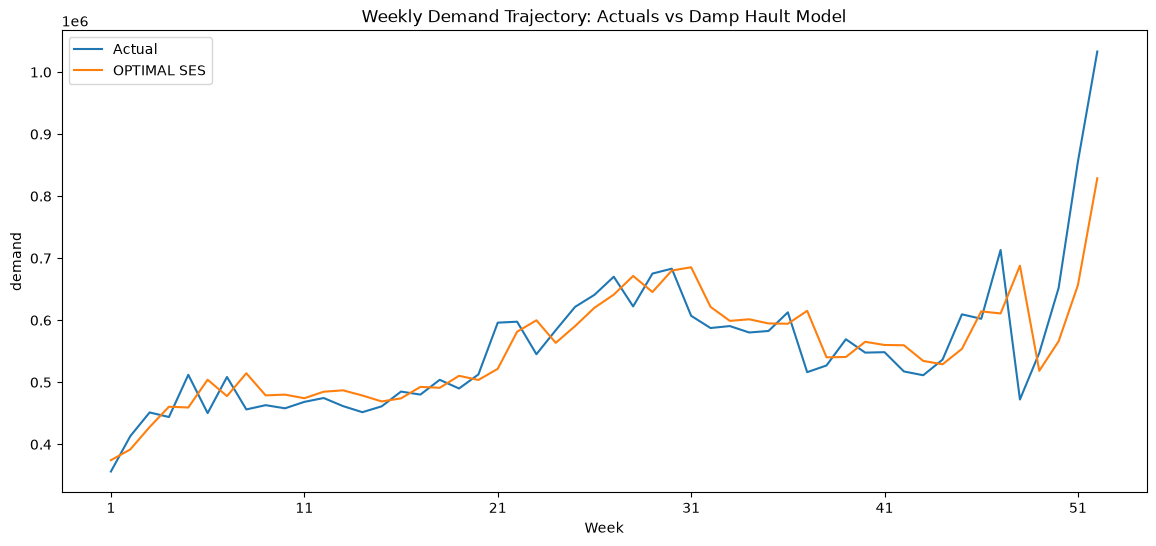

In [181]:
PermanentX_DHAULT_graph.plot(figsize=(14, 6) ,xlabel='Week',ylabel='demand',title="Weekly Demand Trajectory: Actuals vs Damp Hault Model" )

In [175]:
PXDHOlT.drop(columns=droping_columns,inplace = True)

The radaaaaaaaan festival

In [176]:
PX_Tournament = pd.DataFrame(
    {
        # Yearly Totals
        'Actual'     : PXSMA.sum(axis=1),
        'SMA_3'      : PXSMA3.sum(axis=1),
        'SMA_4'      : PXSMA4.sum(axis=1),
        'SMA_5'      : PXSMA5.sum(axis=1),
        'SMA_8'      : PXSMA8.sum(axis=1),
        'SMA_13'     : PXSMA13.sum(axis=1),


        # Net Error (Bias) per SKU
        'S_Bias_3'     : (PXSMA.sum(axis=1) - PXSMA3.sum(axis=1)) / PXSMA.sum(axis=1),
        'S_Bias_4'     : (PXSMA.sum(axis=1) - PXSMA4.sum(axis=1)) / PXSMA.sum(axis=1),
        'S_Bias_5'     : (PXSMA.sum(axis=1) - PXSMA5.sum(axis=1)) / PXSMA.sum(axis=1),
        'S_Bias_8'     : (PXSMA.sum(axis=1) - PXSMA8.sum(axis=1)) / PXSMA.sum(axis=1),
        'S_Bias_13'    : (PXSMA.sum(axis=1) - PXSMA13.sum(axis=1)) / PXSMA.sum(axis=1),

        # Weekly Absolute Error (wMAPE) per SKU — prevents cancellation
        'S_wMAPE_3'    : (PXSMA - PXSMA3).abs().sum(axis=1) / PXSMA.sum(axis=1),
        'S_wMAPE_4'    : (PXSMA - PXSMA4).abs().sum(axis=1) / PXSMA.sum(axis=1),
        'S_wMAPE_5'    : (PXSMA - PXSMA5).abs().sum(axis=1) / PXSMA.sum(axis=1),
        'S_wMAPE_8'    : (PXSMA - PXSMA8).abs().sum(axis=1) / PXSMA.sum(axis=1),
        'S_wMAPE_13'   : (PXSMA - PXSMA13).abs().sum(axis=1) / PXSMA.sum(axis=1),

        # Weekly WMA

        'WMA_3'      : PXWMA3.sum(axis=1),
        'WMA_4'      : PXWMA4.sum(axis=1),
        'WMA_5'      : PXWMA5.sum(axis=1),
        'WMA_8'      : PXWMA8.sum(axis=1),
        'WMA_13'     : PXWMA13.sum(axis=1),

        # Net Error (Bias) per SKU
        'W_Bias_3'     : (PXWMA.sum(axis=1) - PXWMA3.sum(axis=1)) / PXWMA.sum(axis=1),
        'W_Bias_4'     : (PXWMA.sum(axis=1) - PXWMA4.sum(axis=1)) / PXWMA.sum(axis=1),
        'W_Bias_5'     : (PXWMA.sum(axis=1) - PXWMA5.sum(axis=1)) / PXWMA.sum(axis=1),
        'W_Bias_8'     : (PXWMA.sum(axis=1) - PXWMA8.sum(axis=1)) / PXWMA.sum(axis=1),
        'W_Bias_13'    : (PXWMA.sum(axis=1) - PXWMA13.sum(axis=1)) / PXWMA.sum(axis=1),

        # Weekly Absolute Error (wMAPE) per SKU — prevents cancellation
        'W_wMAPE_3'    : (PXWMA - PXWMA3).abs().sum(axis=1) / PXWMA.sum(axis=1),
        'W_wMAPE_4'    : (PXWMA - PXWMA4).abs().sum(axis=1) / PXWMA.sum(axis=1),
        'W_wMAPE_5'    : (PXWMA - PXWMA5).abs().sum(axis=1) / PXWMA.sum(axis=1),
        'W_wMAPE_8'    : (PXWMA - PXWMA8).abs().sum(axis=1) / PXWMA.sum(axis=1),
        'W_wMAPE_13'   : (PXWMA - PXWMA13).abs().sum(axis=1) / PXWMA.sum(axis=1),

        #optimal Simple Exponential smoothing
        'O_SES' : PXSES.sum(axis=1),
        # Net Error (Bias) per SKU
        'E_Bias'     : (PXWMA.sum(axis=1) - PXSES.sum(axis=1)) / PXWMA.sum(axis=1),
        # Weekly Absolute Error (wMAPE) per SKU — prevents cancellation
        'E_wMAPE'    : (PXWMA - PXSES).abs().sum(axis=1) / PXWMA.sum(axis=1),

        #Holt linear Exponential smoothing
        'Holt' : PXHOLT.sum(axis=1),
        # Net Error (Bias) per SKU
        'H_Bias'     : (PXWMA.sum(axis=1) - PXHOLT.sum(axis=1)) / PXWMA.sum(axis=1),
        # Weekly Absolute Error (wMAPE) per SKU — prevents cancellation
        'H_wMAPE'    : (PXWMA - PXHOLT).abs().sum(axis=1) / PXWMA.sum(axis=1),

        #damping Holt linear Exponential smoothing

        'DHolt' : PXDHOlT.sum(axis=1),
        # Net Error (Bias) per SKU
        'D_Bias'     : (PXWMA.sum(axis=1) - PXDHOlT.sum(axis=1)) / PXWMA.sum(axis=1),
        # Weekly Absolute Error (wMAPE) per SKU — prevents cancellation
        'D_wMAPE'    : (PXWMA - PXDHOlT).abs().sum(axis=1) / PXWMA.sum(axis=1)
                }
)

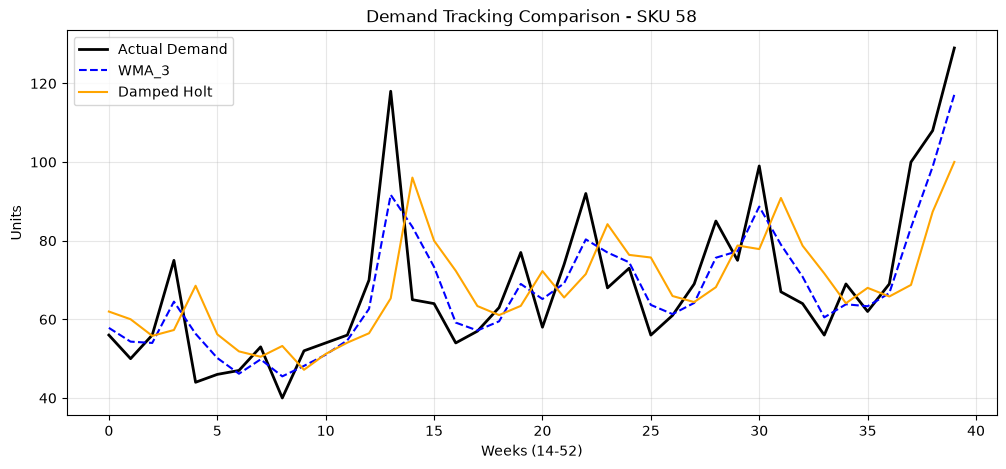

In [180]:
import matplotlib.pyplot as plt

sku_idx = 0  # Select any SKU index

plt.figure(figsize=(12, 5))
plt.plot(PXWMA.iloc[sku_idx].values, label='Actual Demand', color='black', lw=2)
plt.plot(PXWMA3.iloc[sku_idx].values, label='WMA_3', linestyle='--', color='blue')
plt.plot(PXDHOlT.iloc[sku_idx].values, label='Damped Holt', linestyle='-', color='orange')

plt.title(f"Demand Tracking Comparison - SKU {PXWMA.index[sku_idx]}")
plt.xlabel("Weeks (14-52)")
plt.ylabel("Units")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [177]:
PX_Tournament

,Actual,SMA_3,SMA_4,SMA_5,SMA_8,SMA_13,S_Bias_3,S_Bias_4,S_Bias_5,S_Bias_8,...,W_wMAPE_13,O_SES,E_Bias,E_wMAPE,Holt,H_Bias,H_wMAPE,DHolt,D_Bias,D_wMAPE
Brand,,,,,,,,,,,,,,,,,,,,,
58,2731.0,2668.66,2640.25,2623.6,2606.89,2578.46,0.022827,0.033230,0.039326,0.045445,...,0.155884,2633.780544,0.035598,0.195861,2730.105211,0.000328,0.195766,2722.075397,0.003268,0.195998
62,2645.0,2568.67,2547.00,2535.4,2534.14,2515.09,0.028858,0.037051,0.041437,0.041913,...,0.228026,2540.978845,0.039327,0.221240,2634.852851,0.003836,0.222149,2629.155881,0.005990,0.222004
63,2371.0,2298.32,2279.25,2266.0,2254.26,2227.69,0.030654,0.038697,0.044285,0.049237,...,0.214256,2269.154580,0.042955,0.220582,2351.643482,0.008164,0.219336,2346.701363,0.010248,0.219044
72,360.0,362.69,364.50,366.8,371.37,375.75,-0.007472,-0.012500,-0.018889,-0.031583,...,0.372472,368.491045,-0.023586,0.403394,379.669905,-0.054639,0.403513,375.657199,-0.043492,0.409572
77,8164.0,7939.70,7877.75,7831.0,7755.54,7669.91,0.027474,0.035062,0.040789,0.050032,...,0.138191,7863.694191,0.036784,0.155097,8115.665453,0.005920,0.149128,8090.564500,0.008995,0.149768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46985,2333.0,2300.68,2287.75,2274.6,2201.39,2107.73,0.013853,0.019396,0.025032,0.056412,...,0.257617,2181.090324,0.065113,0.294329,2395.520418,-0.026798,0.292952,2171.009993,0.069434,0.293813
47009,1804.0,1757.33,1744.00,1731.4,1718.97,1707.08,0.025870,0.033259,0.040244,0.047134,...,0.311031,1710.581416,0.051784,0.347864,1767.250957,0.020371,0.355236,1806.861187,-0.001586,0.356420
47014,3470.0,3417.34,3405.75,3396.2,3366.36,3326.35,0.015176,0.018516,0.021268,0.029867,...,0.240467,3405.842481,0.018489,0.243750,3478.386022,-0.002417,0.241606,3411.723698,0.016794,0.243108


In [178]:
# Clean metric lists
Bias = [
    'S_Bias_3', 'S_Bias_4', 'S_Bias_5', 'S_Bias_8', 'S_Bias_13',
    'W_Bias_3', 'W_Bias_4', 'W_Bias_5', 'W_Bias_8', 'W_Bias_13',
    'E_Bias' , 'H_Bias', 'D_Bias'
]

wMape = [
    'S_wMAPE_3', 'S_wMAPE_4', 'S_wMAPE_5', 'S_wMAPE_8', 'S_wMAPE_13',
    'W_wMAPE_3', 'W_wMAPE_4', 'W_wMAPE_5', 'W_wMAPE_8', 'W_wMAPE_13',
    'E_wMAPE', 'H_wMAPE', 'D_wMAPE'
]

# Champion assignment
PX_Tournament['Bias'] = (
    PX_Tournament[Bias]
    .abs()
    .idxmin(axis=1)
    .str.replace('S_Bias_', 'SMA_')
    .str.replace('W_Bias_', 'WMA_')
    .str.replace('E_Bias', 'O_SES')
    .str.replace('H_Bias', 'Holt')
    .str.replace('D_Bias', 'DHolt')
)

PX_Tournament['wMape'] = (
    PX_Tournament[wMape]
    .idxmin(axis=1)
    .str.replace('S_wMAPE_', 'SMA_')
    .str.replace('W_wMAPE_', 'WMA_')
    .str.replace('E_wMAPE', 'O_SES')
    .str.replace('H_wMAPE', 'Holt')
    .str.replace('D_wMAPE', 'DHolt')
)

In [179]:
print(PX_Tournament['Bias'].value_counts())
print(PX_Tournament['wMape'].value_counts())

Bias
Holt      1629
WMA_3     1150
DHolt      674
SMA_13     129
O_SES       89
WMA_13      84
SMA_8       75
SMA_5       65
WMA_8       64
SMA_4       49
SMA_3       39
WMA_4       36
WMA_5       29
Name: count, dtype: int64
wMape
WMA_3    4104
SMA_3       8
Name: count, dtype: int64
